# ENSADUL 2022 — Guanajuato
## Limpieza de Datos y Análisis Exploratorio (EDA)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from IPython.display import display

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('future.no_silent_downcasting', True)

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 10

---
## 1. Carga de datos

In [2]:
df = pd.read_csv('../data/raw/2022/ensadul2022_entrega_w_GTO.csv', sep=';', low_memory=False)
df.shape

(1227, 572)

In [3]:
# Cargar catálogo (header en fila 17)
catalog = pd.read_excel('../data/raw/2022/ensadul2022_entrega_w_GTO.Catlogo.xlsx',
                        sheet_name='Variables', skiprows=16)
print(catalog.columns.tolist())
catalog.head()

['Variable', 'Posición', 'Etiqueta', 'Nivel de medición', 'Ancho de columna']


,Variable,Posición,Etiqueta,Nivel de medición,Ancho de columna
0,FOLIO_I,1.0,Folio,Nominal,15.0
1,FOLIO_INT,2.0,Folio integrante,Nominal,22.0
2,t_hora,3.0,TIEMPO HORA,Escala,8.0
3,t_min,4.0,TIEMPO MINUTOS,Escala,8.0
4,t_sumai,5.0,TIEMPO SUMA INICIO,Escala,8.0


In [4]:
# Renombrar columnas con etiquetas del catálogo
col_mapping = dict(zip(catalog['Variable'], catalog['Etiqueta']))
df.rename(columns=col_mapping, inplace=True)
df_original = df.copy()  # Respaldo antes de cualquier limpieza

---
## 2. Limpieza de datos

### 2.1 Reemplazar espacios en blanco y strings vacíos por NaN

In [5]:
df.replace(' ', np.nan, inplace=True)
df.replace('', np.nan, inplace=True)

# Verificar ejemplo previo
print("Valores únicos en consentimiento:", df['Concentimiento para realizar la entrevista'].value_counts(dropna=False).to_dict())
print("Filas totales:", len(df))

Valores únicos en consentimiento: {1: 1227}
Filas totales: 1227


### 2.2 Eliminar columnas con >70% de valores nulos

In [6]:
threshold = len(df) * 0.30   # al menos 30% de datos válidos
df = df.dropna(thresh=threshold, axis=1)

cols_eliminadas = set(df_original.columns) - set(df.columns)
print(f'Columnas eliminadas: {len(cols_eliminadas)}')
print(f'Columnas restantes:  {len(df.columns)}')

Columnas eliminadas: 313
Columnas restantes:  140


### 2.3 Eliminar columnas con menos de 1 000 valores no nulos

In [7]:
antes = len(df.columns)
for col in list(df.columns):
    if df[col].count() < 1000:
        df.drop(col, axis=1, inplace=True)

print(f'Columnas eliminadas: {antes - len(df.columns)}')
print(f'Columnas restantes:  {len(df.columns)}')

Columnas eliminadas: 27
Columnas restantes:  113


### 2.4 Eliminar columnas NOTA (solo metadatos de campo)

In [8]:
notas = [c for c in df.columns if 'NOTA' in c]
print(f'Columnas NOTA encontradas: {len(notas)}')
for c in notas:
    df.drop(c, axis=1, inplace=True)
print(f'Columnas restantes: {len(df.columns)}')

Columnas NOTA encontradas: 22


Columnas restantes: 91


### 2.5 Eliminar columnas constantes o puramente administrativas

In [9]:
# Columnas constantes (un solo valor único) — no aportan información
constantes = [c for c in df.columns if df[c].nunique(dropna=True) <= 1]
print('Columnas constantes:', constantes)
df.drop(columns=constantes, inplace=True)

# Columnas administrativas / logísticas que no son variables de análisis
admin_cols = [
    'Folio', 'Folio integrante',
    'TIEMPO HORA', 'TIEMPO MINUTOS', 'TIEMPO SUMA INICIO', 'TIEMPO SUMA FIN',
    'Hora de Inicio 1', 'Fecha de Inicio 1', 'Hora termino 1', 'Fecha termino 1',
    'Hora de Inicio', 'Fecha de inicio', 'Hora de termino', 'Fecha de Termino',
    'Duración de la Entrevista 1', 'Resultado de entrevista 1',
    'Duración de la Entrevista 2', 'Resultado de entrevista 2',
    'Duración de la Entrevista 3', 'Resultado de entrevista 3',
    'Duración de la Entrevista 4', 'Resultado de entrevista 4',
    'Duración de la Entrevista', 'Resultado de Entrevista',
    'Concentimiento para realizar la entrevista',  # todos = 1
    'Region o zona de trabajo',  # todos = 4 (GTO)
    'Entidad', 'DESC_ENT',       # todos = Guanajuato
    'Fecha de Nacimiento',       # ya tenemos edad
]
admin_cols = [c for c in admin_cols if c in df.columns]
df.drop(columns=admin_cols, inplace=True)
print(f'Columnas administrativas eliminadas: {len(admin_cols)}')
print(f'Columnas restantes: {len(df.columns)}')

Columnas constantes: ['Entidad', 'DESC_ENT', 'Concentimiento para realizar la entrevista', 'Resultado de Entrevista', 'Region o zona de trabajo']
Columnas administrativas eliminadas: 24
Columnas restantes: 62


### 2.6 Corregir tipos de datos

In [10]:
# Columnas object que deberían ser numéricas
cols_to_numeric = [
    '¿Su HERMANO(A) tiene o tuvo diabetes o azúcar alta en la sangre?',
    '¿Su HERMANO(A) tiene o tuvo hipertensión o presión alta?',
    '¿Su HERMANO(A)  tuvo un infarto?',
    'A1001G g) detección de diabetes?',
    'A1305 En el pasado¿ha fumado productos del tabaco…',
    'A1404B ¿Tiene dificultades para oír?',
]
cols_to_numeric = [c for c in cols_to_numeric if c in df.columns]

for col in cols_to_numeric:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Ponderador: coma decimal → punto decimal
if 'Ponderador' in df.columns:
    df['Ponderador'] = (df['Ponderador']
                        .astype(str)
                        .str.replace(',', '.', regex=False))
    df['Ponderador'] = pd.to_numeric(df['Ponderador'], errors='coerce')

# Unidad primaria de muestreo
if 'Unidad primaria de muestreo' in df.columns:
    df['Unidad primaria de muestreo'] = pd.to_numeric(
        df['Unidad primaria de muestreo'], errors='coerce')

print("Tipos después de conversión:")
print(df.dtypes.value_counts())

Tipos después de conversión:
int64      53
float64     8
object      1
Name: count, dtype: int64


### 2.7 Verificar duplicados

In [11]:
print(f'Filas duplicadas: {df.duplicated().sum()}')
print(f'Shape final del dataset: {df.shape}')

Filas duplicadas: 0
Shape final del dataset: (1227, 62)


### 2.8 Revisar nulos restantes

In [12]:
null_pct = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)
null_pct = null_pct[null_pct > 0]
print(f'Columnas con valores nulos: {len(null_pct)}')
print()
print(null_pct.to_string())

Columnas con valores nulos: 7

A1305 En el pasado¿ha fumado productos del tabaco…                  15.240424
A1001G g) detección de diabetes?                                    13.121434
¿Su HERMANO(A) tiene o tuvo diabetes o azúcar alta en la sangre?    10.920945
¿Su HERMANO(A) tiene o tuvo hipertensión o presión alta?            10.920945
¿Su HERMANO(A)  tuvo un infarto?                                    10.920945
Unidad primaria de muestreo                                          6.193969
A1404B ¿Tiene dificultades para oír?                                 1.222494


### 2.9 Análisis e imputación de valores nulos

A continuación se analiza cada columna con valores nulos, se justifica la estrategia de imputación y se aplica.

#### Variable 1/6 — `A1305` ¿Ha fumado en el pasado?

In [13]:
col_actual = 'A1301 Actualmente, ¿fuma tabaco…'
col_pasado = 'A1305 En el pasado¿ha fumado productos del tabaco…'

print("Distribución de A1305 (tabaco pasado):")
print(df[col_pasado].value_counts(dropna=False).rename({1:'Diariamente',2:'Ocasionalmente',3:'No fumaba',float('nan'):'Nulo'}))
print()
print("Valores de A1301 en las filas donde A1305 es nulo:")
print(df.loc[df[col_pasado].isna(), col_actual].value_counts(dropna=False).rename({1:'Actualmente diario',2:'Actualmente ocas.',9:'No sabe'}))

Distribución de A1305 (tabaco pasado):
A1305 En el pasado¿ha fumado productos del tabaco…
No fumaba         867
NaN               187
Ocasionalmente    110
Diariamente        63
Name: count, dtype: int64

Valores de A1301 en las filas donde A1305 es nulo:
A1301 Actualmente, ¿fuma tabaco…
Actualmente diario    111
Actualmente ocas.      74
No sabe                 2
Name: count, dtype: int64


In [ ]:
# Análisis
# Los 187 nulos de A1305 corresponden EXACTAMENTE a fumadores ACTUALES (A1301=1 o 2)
# y a 2 casos con A1301=9 (no sabe). La pregunta A1305 solo se hace a quienes
# ya no fuman (lógica de salto de encuesta). Los nulos son ESTRUCTURALES, no aleatorios.
#
# Estrategia: asignar categoría 0 = "Actualmente fuma" para no perder esa
# información ni mezclarlos con "Nunca fumó" (=3) o "Fumaba antes" (=1,2).

df[col_pasado] = df[col_pasado].fillna(0)

print("Distribución final de A1305:")
label_map = {0:'Actualmente fuma',1:'Fumaba (diario)',2:'Fumaba (ocas.)',3:'Nunca fumó'}
print(df[col_pasado].map(label_map).value_counts())
print(f"Nulos restantes: {df[col_pasado].isna().sum()}")

Distribución final de A1305:
A1305 En el pasado¿ha fumado productos del tabaco…
Nunca fumó          867
Actualmente fuma    187
Fumaba (ocas.)      110
Fumaba (diario)      63
Name: count, dtype: int64
Nulos restantes: 0


#### Variable 2/6 — `A1001G` Detección de diabetes

In [15]:
col_g = 'A1001G g) detección de diabetes?'
col_f = 'A1001F f) detección de sobrepeso u obesidad?'

print("Distribución de A1001G (detección de diabetes):")
print(df[col_g].value_counts(dropna=False).rename({'1':'Sí','2':'No'}))
print()
print("A1001F en las filas donde A1001G es nulo:")
if col_f in df.columns:
    print(df.loc[df[col_g].isna(), col_f].value_counts(dropna=False).rename({1:'Sí',2:'No'}))

Distribución de A1001G (detección de diabetes):
A1001G g) detección de diabetes?
2.0    931
NaN    161
1.0    135
Name: count, dtype: int64

A1001F en las filas donde A1001G es nulo:
A1001F f) detección de sobrepeso u obesidad?
No    133
Sí     28
Name: count, dtype: int64


In [ ]:
# Análisis
# 161 nulos (13.1%). El 82.6% de esos nulos corresponde a personas que TAMPOCO
# tuvieron detección de obesidad (A1001F=2), lo que sugiere que nunca asistieron
# a ninguna detección. El 17.4% sí tuvo detección de obesidad pero no contestó
# si tuvieron detección de diabetes.
#
# La variable es binaria (1=Sí, 2=No). El 87.3% de respuestas válidas = No.
#
# Estrategia: imputar con la MODA = 2 (No). La ausencia de detección es
# consistente con el patrón observado en A1001F y con la mayoría de respuestas.

moda_g = int(df[col_g].mode()[0])
df[col_g] = df[col_g].fillna(moda_g)

print(f"Imputado con moda = {moda_g} (No)")
print(f"Distribución final: {df[col_g].value_counts().to_dict()}")
print(f"Nulos restantes: {df[col_g].isna().sum()}")

Imputado con moda = 2 (No)
Distribución final: {2.0: 1092, 1.0: 135}
Nulos restantes: 0


#### Variables 3–5/6 — Antecedentes familiares: hermano(a)

In [17]:
col_herm_ref = 'Tiene/Tuvo usted hermanos(as)'
herm_cols = {
    'Diab. hermano(a)':    '¿Su HERMANO(A) tiene o tuvo diabetes o azúcar alta en la sangre?',
    'Hiper. hermano(a)':   '¿Su HERMANO(A) tiene o tuvo hipertensión o presión alta?',
    'Infarto hermano(a)':  '¿Su HERMANO(A)  tuvo un infarto?',
}

print(f"Nulos por columna: {df[[v for v in herm_cols.values()]].isnull().sum().to_dict()}")
print()
print("Valor de 'Tiene/Tuvo hermanos(as)' en filas con nulos:")
col_ref_check = herm_cols['Diab. hermano(a)']
print(df.loc[df[col_ref_check].isna(), col_herm_ref].value_counts(dropna=False)
      .rename({1:'Sí tiene hermanos',2:'No tiene hermanos'}))

Nulos por columna: {'¿Su HERMANO(A) tiene o tuvo diabetes o azúcar alta en la sangre?': 134, '¿Su HERMANO(A) tiene o tuvo hipertensión o presión alta?': 134, '¿Su HERMANO(A)  tuvo un infarto?': 134}

Valor de 'Tiene/Tuvo hermanos(as)' en filas con nulos:
Tiene/Tuvo usted hermanos(as)
No tiene hermanos    134
Name: count, dtype: int64


In [ ]:
# Análisis
# Los 134 nulos en las 3 columnas de hermanos provienen EXACTAMENTE de las
# personas que respondieron "No" a "¿Tiene/Tuvo hermanos(as)?" (valor 2).
# Son nulos ESTRUCTURALES por lógica de salto: sin hermanos, las preguntas
# de antecedentes familiares de hermanos no aplican.
#
# Valores posibles: 1=Sí, 2=No, 9=No sabe.
#
# Estrategia: imputar con 2 (No). Si no se tiene hermanos, efectivamente
# ningún hermano tiene la enfermedad en cuestión. Esta es la imputación más
# coherente con el diseño de la encuesta.

for label, col in herm_cols.items():
    df[col] = df[col].fillna(2)
    print(f"{label}: nulos restantes = {df[col].isna().sum()} | dist = {df[col].value_counts().to_dict()}")

Diab. hermano(a): nulos restantes = 0 | dist = {2.0: 866, 1.0: 353, 9.0: 8}
Hiper. hermano(a): nulos restantes = 0 | dist = {2.0: 943, 1.0: 267, 9.0: 17}
Infarto hermano(a): nulos restantes = 0 | dist = {2.0: 1186, 1.0: 31, 9.0: 10}


#### Variable 6/6 — Unidad primaria de muestreo

In [19]:
col_upm = 'Unidad primaria de muestreo'
print("Nulos:", df[col_upm].isna().sum())
print("Tipo de dato:", df[col_upm].dtype)
print("Muestra de valores:", df[col_upm].dropna().unique()[:5])
print()
print("Esta columna contiene identificadores alfanuméricos del marco muestral")
print("(ej. '1103200000017', '110140000017A'). Es una variable puramente")
print("administrativa de diseño muestral, sin contenido analítico de salud.")

Nulos: 76
Tipo de dato: float64
Muestra de valores: [1.10010000e+12 1.10010000e+12 1.10030001e+12 1.10030000e+12
 1.10070001e+12]

Esta columna contiene identificadores alfanuméricos del marco muestral
(ej. '1103200000017', '110140000017A'). Es una variable puramente
administrativa de diseño muestral, sin contenido analítico de salud.


In [ ]:
# Análisis
# La UPM es un identificador del diseño de muestreo complejo, no una variable
# de salud o sociodemográfica analítica. Imputarla con la moda introduciría
# sesgos en el análisis estadístico de estimaciones poblacionales.
#
# Estrategia: ELIMINAR la columna del dataset analítico. El Ponderador
# (que sí se conservó) es suficiente para ajustar por diseño muestral cuando
# se requiera. La UPM solo es necesaria para análisis de errores estándar
# con software especializado (svy en Stata, survey en R).

df.drop(columns=[col_upm], inplace=True)
print(f"Columna '{col_upm}' eliminada.")
print(f"Shape del dataset: {df.shape}")

Columna 'Unidad primaria de muestreo' eliminada.
Shape del dataset: (1227, 61)


#### (Adicional) — `A1404B` Dificultades para oír  
> *Esta columna quedó con 15 nulos (1.2%) tras la conversión de tipo.*

In [21]:
col_oir = 'A1404B ¿Tiene dificultades para oír?'
print("Distribución de A1404B:")
label_oir = {1:'No tiene dificultad', 2:'Tiene dificultad', 3:'No puede'}
print(df[col_oir].value_counts(dropna=False).rename(label_oir))
print(f"Moda = {int(df[col_oir].mode()[0])} ({label_oir.get(int(df[col_oir].mode()[0]))})")

Distribución de A1404B:
A1404B ¿Tiene dificultades para oír?
No tiene dificultad    1087
Tiene dificultad        112
NaN                      15
No puede                 13
Name: count, dtype: int64
Moda = 1 (No tiene dificultad)


In [ ]:
# Análisis
# Solo 15 nulos (1.2%) — proporción mínima. Variable ordinal categórica:
#   1 = Sin dificultad  (88.6% de respuestas válidas)
#   2 = Con dificultad  ( 9.1%)
#   3 = No puede         ( 1.1%)
#
# Estrategia: imputar con la MODA = 1 (Sin dificultad). Con tan pocos nulos
# y una moda tan dominante, el impacto en los análisis es despreciable.

moda_oir = int(df[col_oir].mode()[0])
df[col_oir] = df[col_oir].fillna(moda_oir)
print(f"Imputado con moda = {moda_oir} (Sin dificultad auditiva)")
print(f"Nulos restantes: {df[col_oir].isna().sum()}")

Imputado con moda = 1 (Sin dificultad auditiva)
Nulos restantes: 0


#### Verificación final — dataset sin nulos

In [23]:
total_nulos = df.isnull().sum().sum()
print(f"Total de valores nulos en el dataset: {total_nulos}")
print(f"Shape final: {df.shape}")
print()
if total_nulos == 0:
    print("✓ El dataset está completamente limpio — sin valores nulos.")
else:
    print("Columnas con nulos restantes:")
    print(df.isnull().sum()[df.isnull().sum() > 0])

Total de valores nulos en el dataset: 0
Shape final: (1227, 61)

✓ El dataset está completamente limpio — sin valores nulos.


### 2.10 Crear variables derivadas

In [24]:
# Grupos etarios
bins   = [20, 30, 40, 50, 60, 70, 80, 100]
labels = ['20-29', '30-39', '40-49', '50-59', '60-69', '70-79', '80+']
df['Grupo etario'] = pd.cut(df['Edad del Seleccionado'], bins=bins,
                             labels=labels, right=False)

# Sexo como etiqueta
df['Sexo'] = df['Sexo del Seleccionado'].map({1: 'Hombre', 2: 'Mujer'})

# Estrato (urbanidad)
df['Urbanidad'] = df['Estrato urbanidad/ruralidad'].map({
    1: 'Rural', 2: 'Semi-urbano', 3: 'Urbano'})

# Municipio limpio
if 'DESC_MUN' in df.columns:
    df['Municipio'] = df['DESC_MUN'].str.replace(r'^\d+\s+', '', regex=True)

# Puntuación depresión (escala CES-D simplificada, 7 ítems)
# Ítems negativos (1=poco, 4=mucho): tristeza, concentración, depresión, esfuerzo,
#   no dormir, sentirse triste (valor directo)
# Ítem positivo (4=mucho): disfrutar la vida (invertir)
dep_neg = [
    'Durante la última semana...¿Sentía como si no pudiera quitarse de encima la tristeza?',
    'Durante la última semana...¿le costaba concentrarse en lo que estaba haciendo?',
    'Durante la última semana...¿se sintió deprimido/a?',
    'Durante la última semana...¿le parecía que todo lo que hacía era un esfuerzo?',
    'Durante la última semana...¿no durmió bien?',
    'Durante la última semana...¿se sintió triste?',
]
dep_pos = ['Durante la última semana...¿disfruto de la vida?']

dep_neg = [c for c in dep_neg if c in df.columns]
dep_pos = [c for c in dep_pos if c in df.columns]

if dep_neg or dep_pos:
    dep_score = df[dep_neg].sum(axis=1)
    for c in dep_pos:
        dep_score += (5 - df[c])   # invertir: 4→1, 1→4
    df['Score depresión'] = dep_score
    print(f'Score depresión calculado (rango: {dep_score.min():.0f}–{dep_score.max():.0f})')

print(f'\nDataset listo para análisis: {df.shape}')

Score depresión calculado (rango: 7–28)

Dataset listo para análisis: (1227, 66)


### 2.11 Resumen del dataset limpio

In [25]:
display(df.describe(include='all').T[['count','unique','top','freq','mean','std','min','max']])

,count,unique,top,freq,mean,std,min,max
Municipio/Alcaldia,1227.0,NaN,NaN,NaN,20.04075,10.90355,1.0,44.0
DESC_MUN,1227,20,020 LEÓN,332,NaN,NaN,NaN,NaN
Edad del Seleccionado,1227.0,NaN,NaN,NaN,46.536267,17.11341,20.0,98.0
Sexo del Seleccionado,1227.0,NaN,NaN,NaN,1.649552,0.477305,1.0,2.0
Meses edad,1227.0,NaN,NaN,NaN,5.392828,3.477105,0.0,11.0
ASEXO ¿Cuál es el sexo de (NOMBRE) ?,1227.0,NaN,NaN,NaN,1.646292,0.478315,1.0,2.0
AEDAD ¿Cuántos años cumplidos tiene actualmente (NOMBRE) ?,1227.0,NaN,NaN,NaN,46.577017,17.124234,20.0,98.0
"Ahora le voy a mostrar unas figuras corporales, por favor, dígame qué figura siente que más se parece a usted en este momento",1227.0,NaN,NaN,NaN,4.805216,1.610135,1.0,9.0
"Durante los últimos 12 meses, ¿ha perdido o ganado peso?",1227.0,NaN,NaN,NaN,2.290139,0.939747,1.0,9.0
Durante la última semana...¿Sentía como si no pudiera quitarse de encima la tristeza?,1227.0,NaN,NaN,NaN,1.445803,0.778559,1.0,4.0


In [26]:
# Exportar dataset limpio a data/processed/
clean_path = '../data/processed/ensadul2022_GTO_clean.csv'
df.to_csv(clean_path, index=False, encoding='utf-8-sig')
print(f'Dataset limpio exportado → {clean_path}')
print(f'Shape: {df.shape}')

Dataset limpio exportado → ../data/processed/ensadul2022_GTO_clean.csv
Shape: (1227, 66)


---
## 3. Análisis Exploratorio de Datos (EDA)

### 3.1 Demografía general

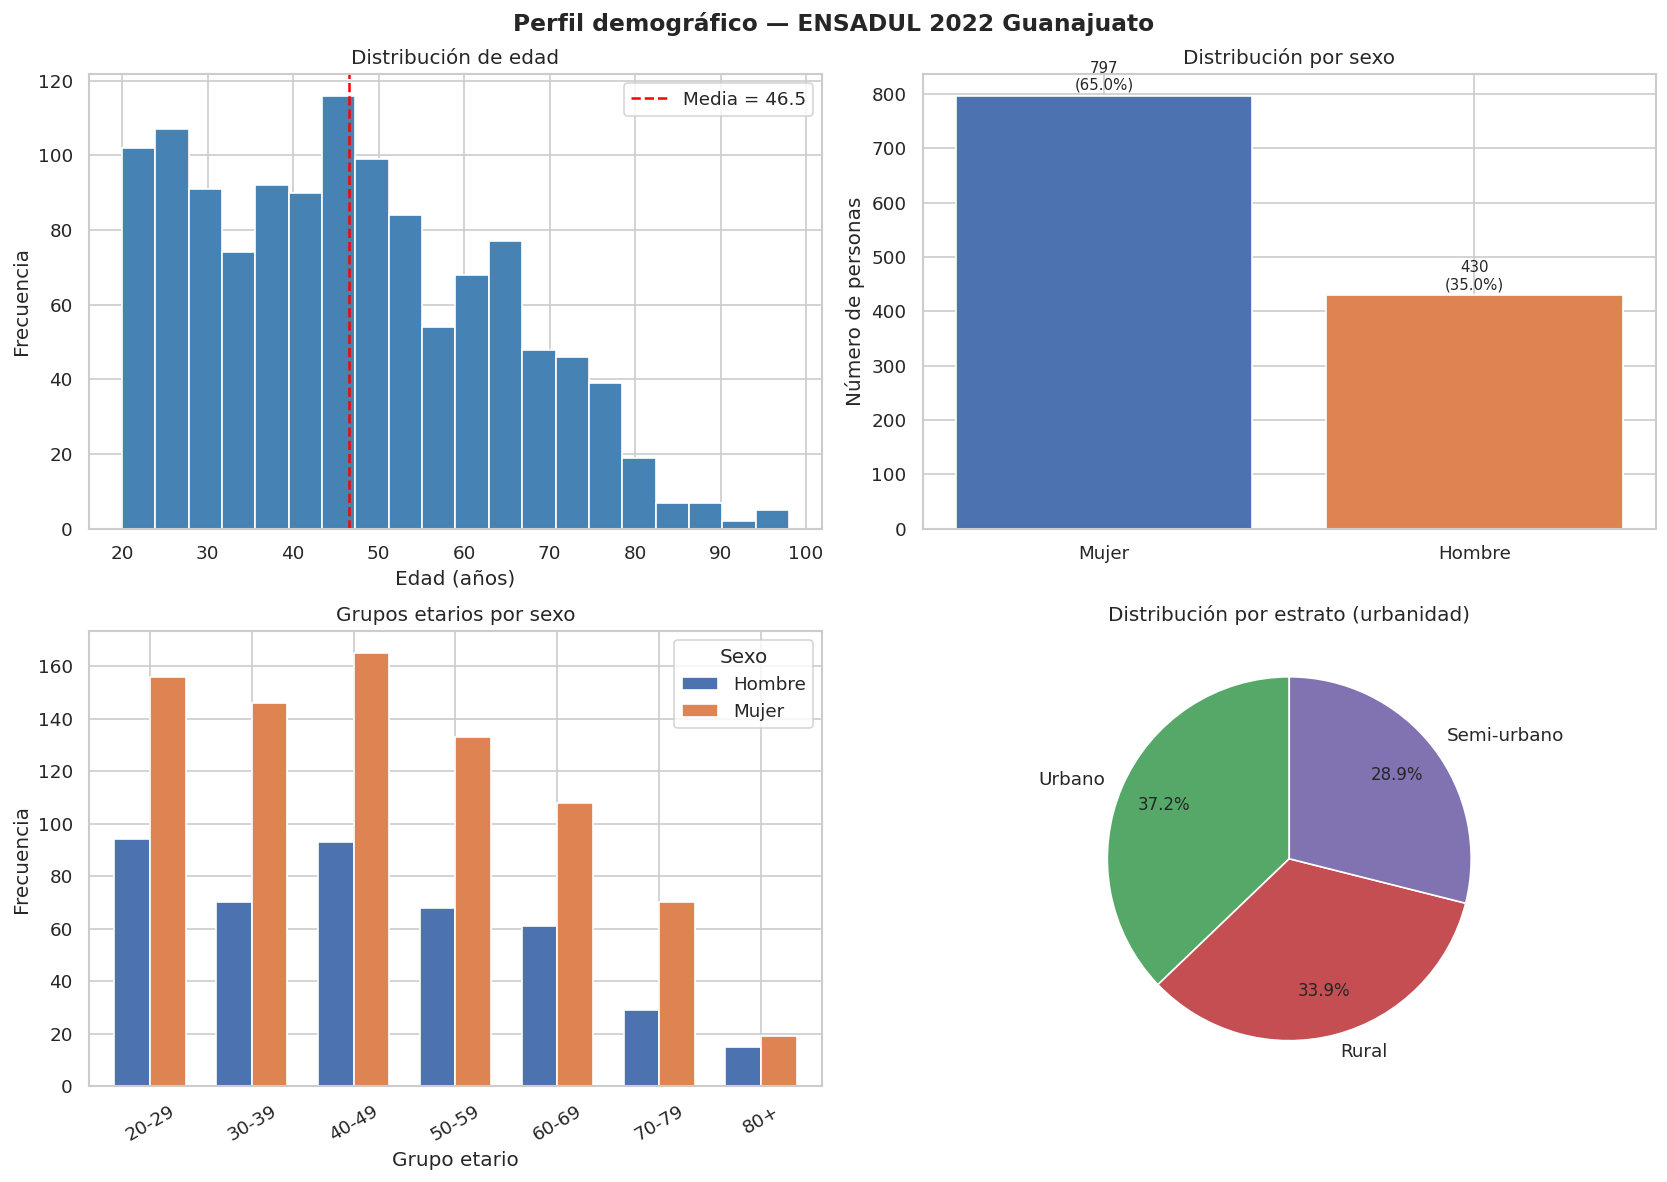

In [27]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Perfil demográfico — ENSADUL 2022 Guanajuato', fontsize=14, fontweight='bold')

# Distribución de edad
ax = axes[0, 0]
ax.hist(df['Edad del Seleccionado'].dropna(), bins=20, color='steelblue', edgecolor='white')
ax.set_title('Distribución de edad')
ax.set_xlabel('Edad (años)')
ax.set_ylabel('Frecuencia')
ax.axvline(df['Edad del Seleccionado'].mean(), color='red', linestyle='--',
           label=f'Media = {df["Edad del Seleccionado"].mean():.1f}')
ax.legend()

# Sexo
ax = axes[0, 1]
sex_counts = df['Sexo'].value_counts()
bars = ax.bar(sex_counts.index, sex_counts.values,
              color=['#4C72B0', '#DD8452'], edgecolor='white')
ax.set_title('Distribución por sexo')
ax.set_ylabel('Número de personas')
for bar, val in zip(bars, sex_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
            f'{val}\n({val/len(df)*100:.1f}%)', ha='center', va='bottom', fontsize=9)

# Grupos etarios por sexo
ax = axes[1, 0]
cross = df.groupby(['Grupo etario', 'Sexo'], observed=True).size().unstack(fill_value=0)
cross.plot(kind='bar', ax=ax, color=['#4C72B0', '#DD8452'], edgecolor='white', width=0.7)
ax.set_title('Grupos etarios por sexo')
ax.set_xlabel('Grupo etario')
ax.set_ylabel('Frecuencia')
ax.legend(title='Sexo')
ax.tick_params(axis='x', rotation=30)

# Urbanidad
ax = axes[1, 1]
urb = df['Urbanidad'].value_counts()
colors_urb = ['#55A868', '#C44E52', '#8172B2']
wedges, texts, autotexts = ax.pie(
    urb.values, labels=urb.index,
    autopct='%1.1f%%', colors=colors_urb,
    startangle=90, pctdistance=0.75)
ax.set_title('Distribución por estrato (urbanidad)')

plt.tight_layout()
plt.savefig('../outputs/figures/2022/eda_demografia.png', bbox_inches='tight')
plt.show()

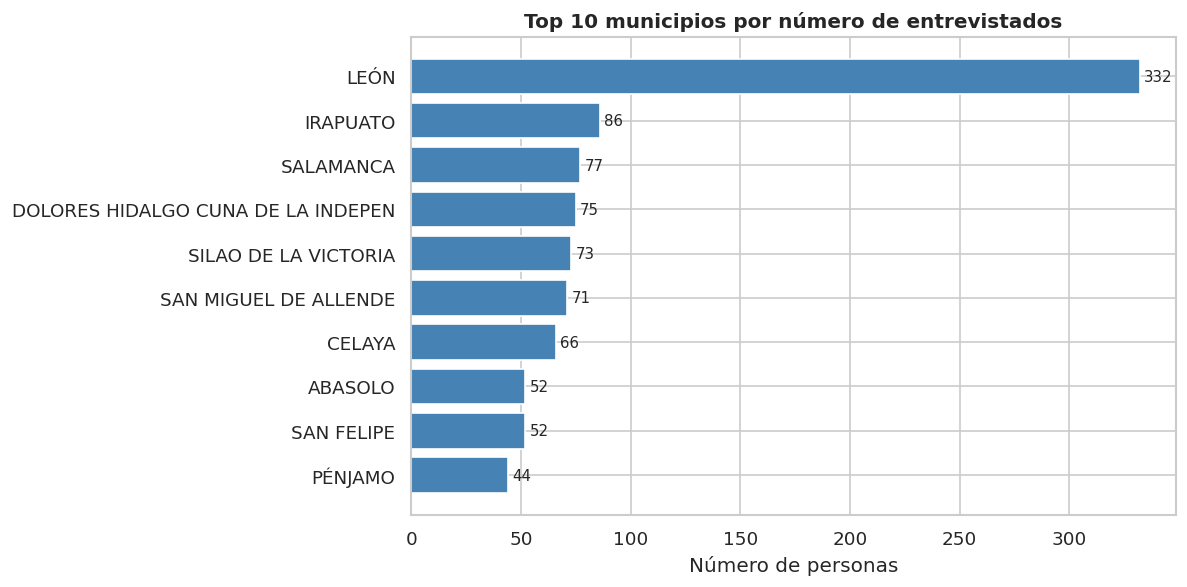

In [28]:
# Municipios con más entrevistados
if 'Municipio' in df.columns:
    mun_top = df['Municipio'].value_counts().head(10)
    fig, ax = plt.subplots(figsize=(10, 5))
    bars = ax.barh(mun_top.index[::-1], mun_top.values[::-1], color='steelblue', edgecolor='white')
    ax.set_title('Top 10 municipios por número de entrevistados', fontweight='bold')
    ax.set_xlabel('Número de personas')
    for bar, val in zip(bars, mun_top.values[::-1]):
        ax.text(bar.get_width() + 2, bar.get_y() + bar.get_height()/2,
                str(val), va='center', fontsize=9)
    plt.tight_layout()
    plt.savefig('../outputs/figures/2022/eda_municipios.png', bbox_inches='tight')
    plt.show()

### 3.2 Prevalencia de enfermedades crónicas

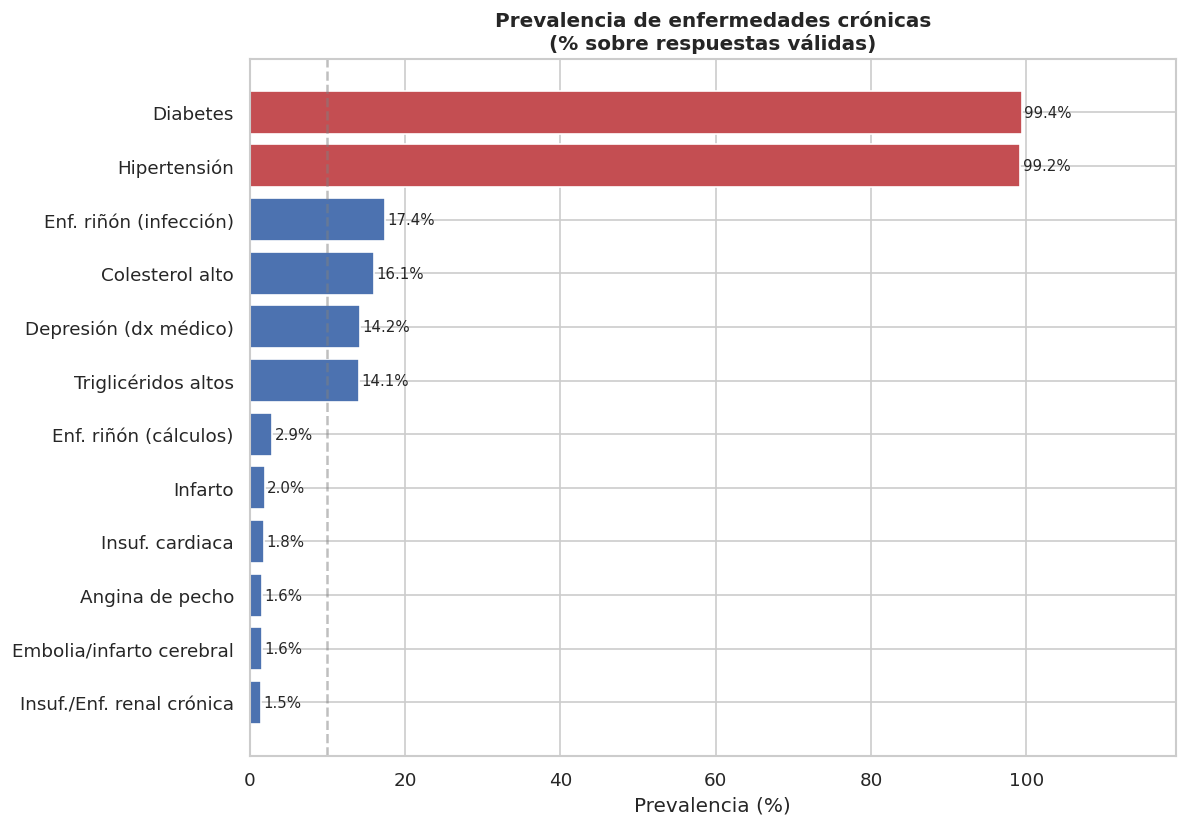

In [29]:
# Columnas de enfermedades (respuesta 1=Sí, 2=No, 9=No sé)
enf_cols = {
    'Diabetes': '¿Algún médico le ha dicho que tiene diabetes (o alta el azúcar en la sangre)?',
    'Hipertensión': '¿Algún médico le ha dicho que tiene la presión alta?',
    'Colesterol alto': '¿Algún médico le ha dicho que tiene el colesterol alto?',
    'Triglicéridos altos': '¿Algún médico le ha dicho que tiene los triglicéridos  altos?',
    'Infarto': '¿Le ha dicho el médico que usted tiene (o tuvo) un infarto o ataque al corazón?',
    'Angina de pecho': '¿Le ha dicho el médico que usted tiene (o tuvo) angina de pecho (dolor o molestia en el pecho, que desaparece regularmente de forma espontánea con el reposo o con medicinas?',
    'Insuf. cardiaca': '¿Le ha dicho el médico que usted tiene (o tuvo) insuficiencia cardiaca (debilitamiento de la capacidad de bombeo del corazón, que provoca edema en pies, tobillos y piernas, cansancio y falta de aire)?',
    'Embolia/infarto cerebral': '¿Le ha dicho el médico que usted tiene (o tuvo) embolia o un infarto cerebral?',
    'Enf. riñón (infección)': '¿Alguna vez un médico le ha dicho que padece de alguna enfermedad del riñón, como infección de vías urinarias en más de una ocasión?',
    'Enf. riñón (cálculos)': '¿Alguna vez un médico le ha dicho que padece de alguna enfermedad del riñón, como cálculos renales?',
    'Insuf./Enf. renal crónica': '¿Alguna vez un médico le ha dicho que padece de alguna enfermedad del riñón, como insuficiencia renal o enfermedad renal crónica?',
    'Depresión (dx médico)': '¿Alguna vez le ha dicho un médico u otra personal de salud que sufre o ha sufrido depresión?',
}

enf_cols = {k: v for k, v in enf_cols.items() if v in df.columns}
prev = {}
for label, col in enf_cols.items():
    total_valido = df[col].isin([1, 2]).sum()
    si = (df[col] == 1).sum()
    prev[label] = si / total_valido * 100 if total_valido > 0 else 0

prev_series = pd.Series(prev).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 7))
colors = ['#C44E52' if v > 20 else '#4C72B0' for v in prev_series.values]
bars = ax.barh(prev_series.index, prev_series.values, color=colors, edgecolor='white')
ax.set_title('Prevalencia de enfermedades crónicas\n(% sobre respuestas válidas)', fontweight='bold')
ax.set_xlabel('Prevalencia (%)')
ax.axvline(10, color='gray', linestyle='--', alpha=0.5)
for bar, val in zip(bars, prev_series.values):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', fontsize=9)
ax.set_xlim(0, prev_series.max() * 1.2)
plt.tight_layout()
plt.savefig('../outputs/figures/2022/eda_enfermedades.png', bbox_inches='tight')
plt.show()

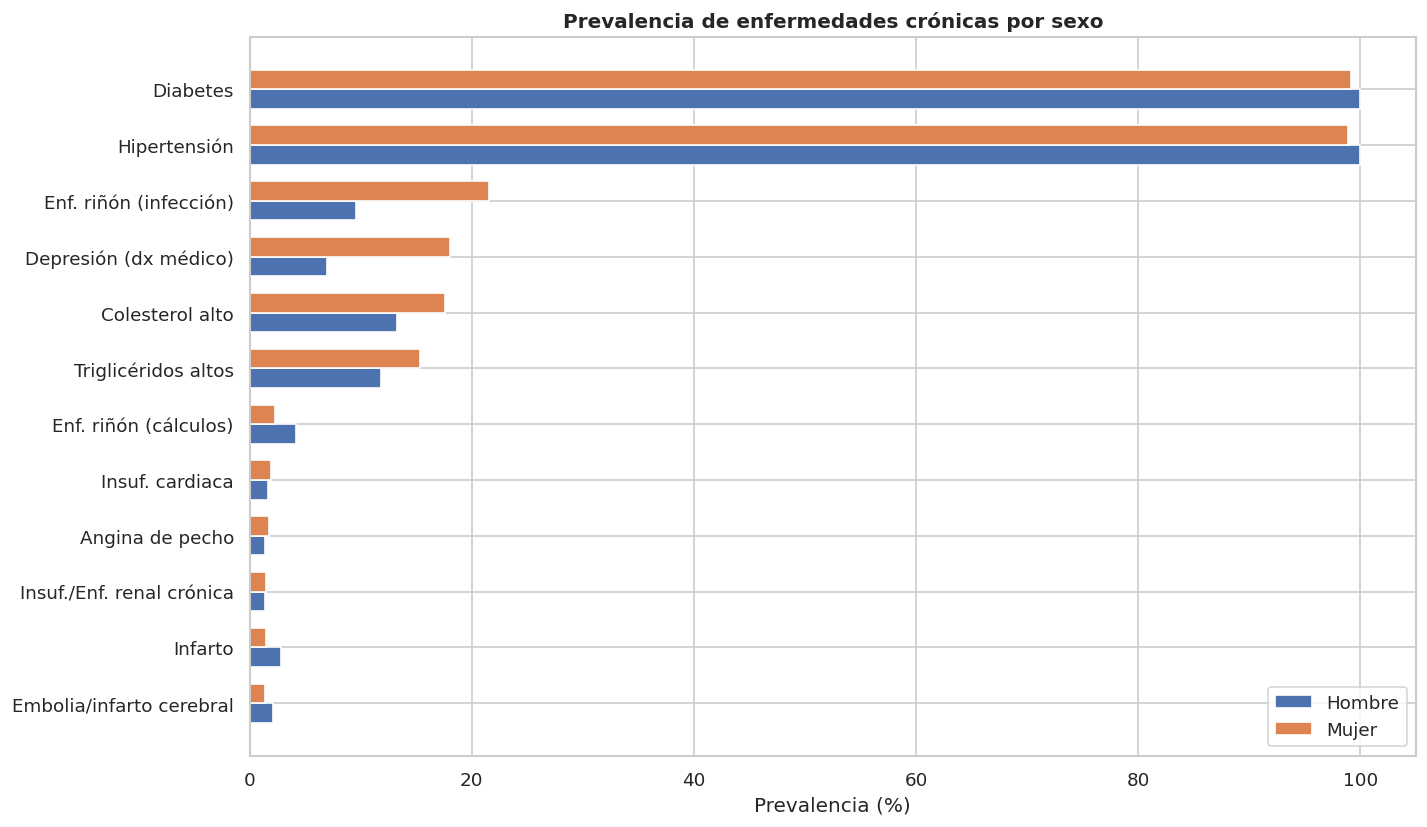

In [30]:
# Prevalencia por sexo
fig, ax = plt.subplots(figsize=(12, 7))
enf_sexo = []
for label, col in enf_cols.items():
    for sexo in ['Hombre', 'Mujer']:
        sub = df[df['Sexo'] == sexo]
        total = sub[col].isin([1, 2]).sum()
        si = (sub[col] == 1).sum()
        pct = si / total * 100 if total > 0 else 0
        enf_sexo.append({'Enfermedad': label, 'Sexo': sexo, 'Prevalencia (%)': pct})

enf_sexo_df = pd.DataFrame(enf_sexo)
pivot = enf_sexo_df.pivot(index='Enfermedad', columns='Sexo', values='Prevalencia (%)').sort_values('Mujer')

x = np.arange(len(pivot))
width = 0.35
bars1 = ax.barh(x - width/2, pivot['Hombre'], width, label='Hombre', color='#4C72B0', edgecolor='white')
bars2 = ax.barh(x + width/2, pivot['Mujer'],  width, label='Mujer',  color='#DD8452', edgecolor='white')
ax.set_yticks(x)
ax.set_yticklabels(pivot.index)
ax.set_xlabel('Prevalencia (%)')
ax.set_title('Prevalencia de enfermedades crónicas por sexo', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('../outputs/figures/2022/eda_enf_sexo.png', bbox_inches='tight')
plt.show()

### 3.3 Salud mental

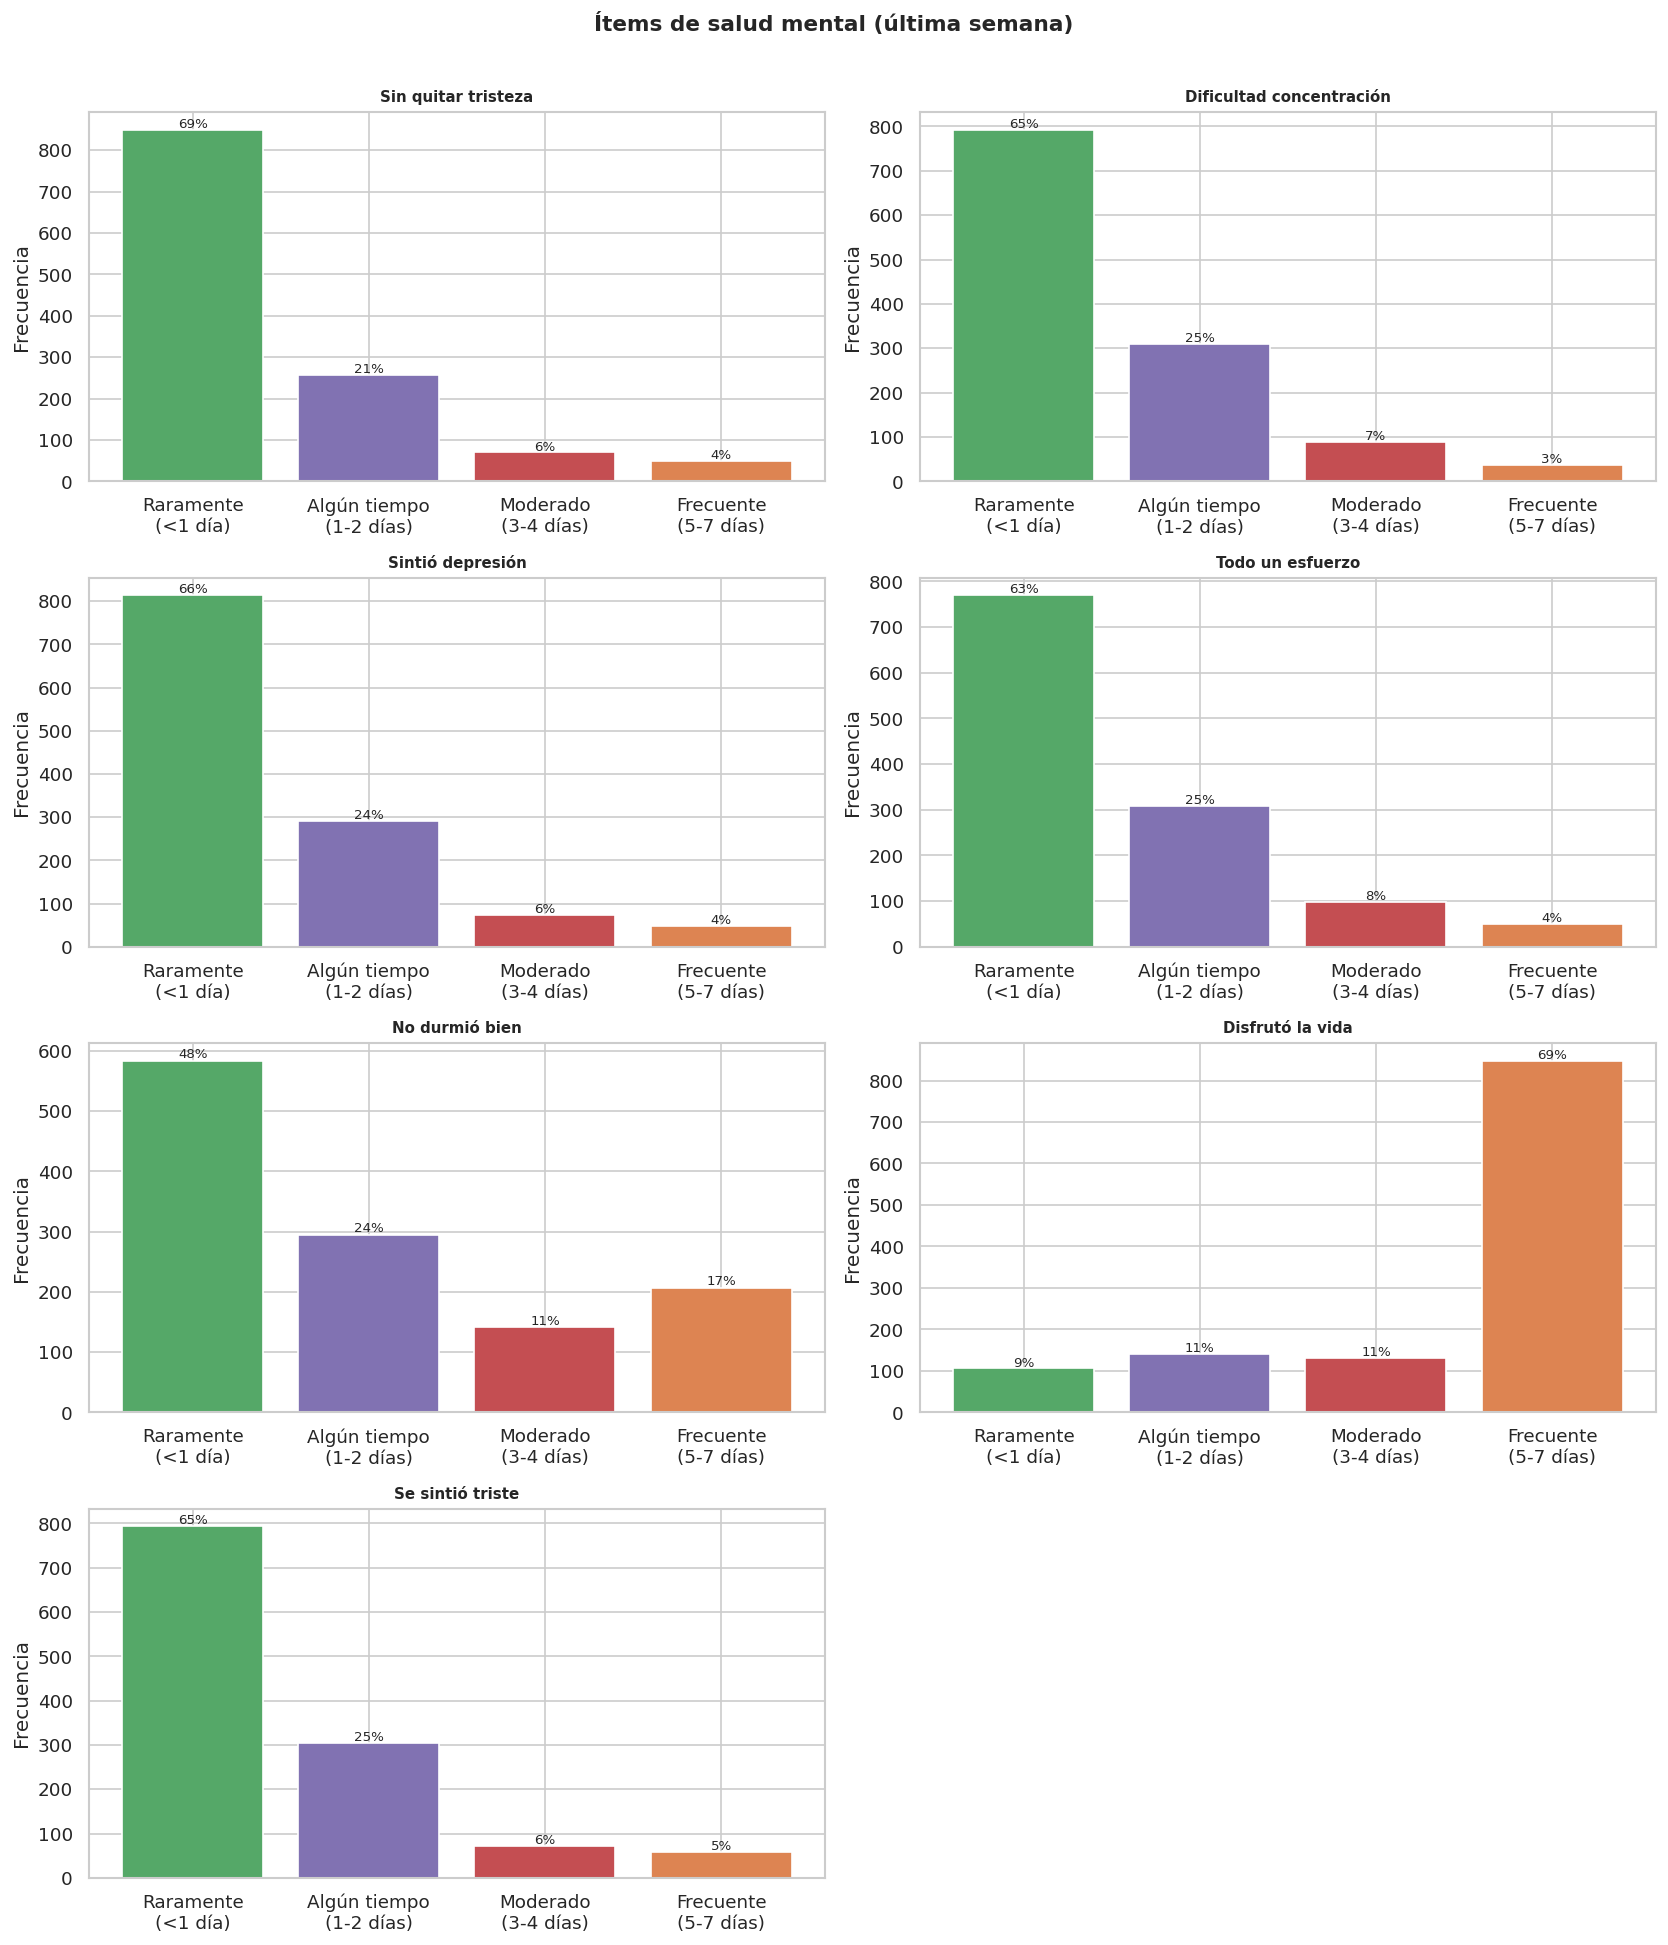

In [31]:
dep_items = {
    'Sin quitar tristeza': 'Durante la última semana...¿Sentía como si no pudiera quitarse de encima la tristeza?',
    'Dificultad concentración': 'Durante la última semana...¿le costaba concentrarse en lo que estaba haciendo?',
    'Sintió depresión': 'Durante la última semana...¿se sintió deprimido/a?',
    'Todo un esfuerzo': 'Durante la última semana...¿le parecía que todo lo que hacía era un esfuerzo?',
    'No durmió bien': 'Durante la última semana...¿no durmió bien?',
    'Disfrutó la vida': 'Durante la última semana...¿disfruto de la vida?',
    'Se sintió triste': 'Durante la última semana...¿se sintió triste?',
}
dep_items = {k: v for k, v in dep_items.items() if v in df.columns}

labels_respuesta = {1: 'Raramente\n(<1 día)', 2: 'Algún tiempo\n(1-2 días)',
                    3: 'Moderado\n(3-4 días)', 4: 'Frecuente\n(5-7 días)'}

fig, axes = plt.subplots(4, 2, figsize=(14, 16))
axes = axes.flatten()
colors_dep = ['#55A868', '#8172B2', '#C44E52', '#DD8452']

for idx, (label, col) in enumerate(dep_items.items()):
    ax = axes[idx]
    counts = df[col].value_counts().sort_index()
    counts.index = [labels_respuesta.get(i, str(i)) for i in counts.index]
    ax.bar(counts.index, counts.values, color=colors_dep, edgecolor='white')
    ax.set_title(label, fontsize=9, fontweight='bold')
    ax.set_ylabel('Frecuencia')
    total = counts.sum()
    for i, (xi, v) in enumerate(zip(counts.index, counts.values)):
        ax.text(i, v + 5, f'{v/total*100:.0f}%', ha='center', fontsize=8)

# Ocultar último subplot si hay espacio vacío
for idx in range(len(dep_items), len(axes)):
    axes[idx].set_visible(False)

fig.suptitle('Ítems de salud mental (última semana)', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../outputs/figures/2022/eda_salud_mental_items.png', bbox_inches='tight')
plt.show()

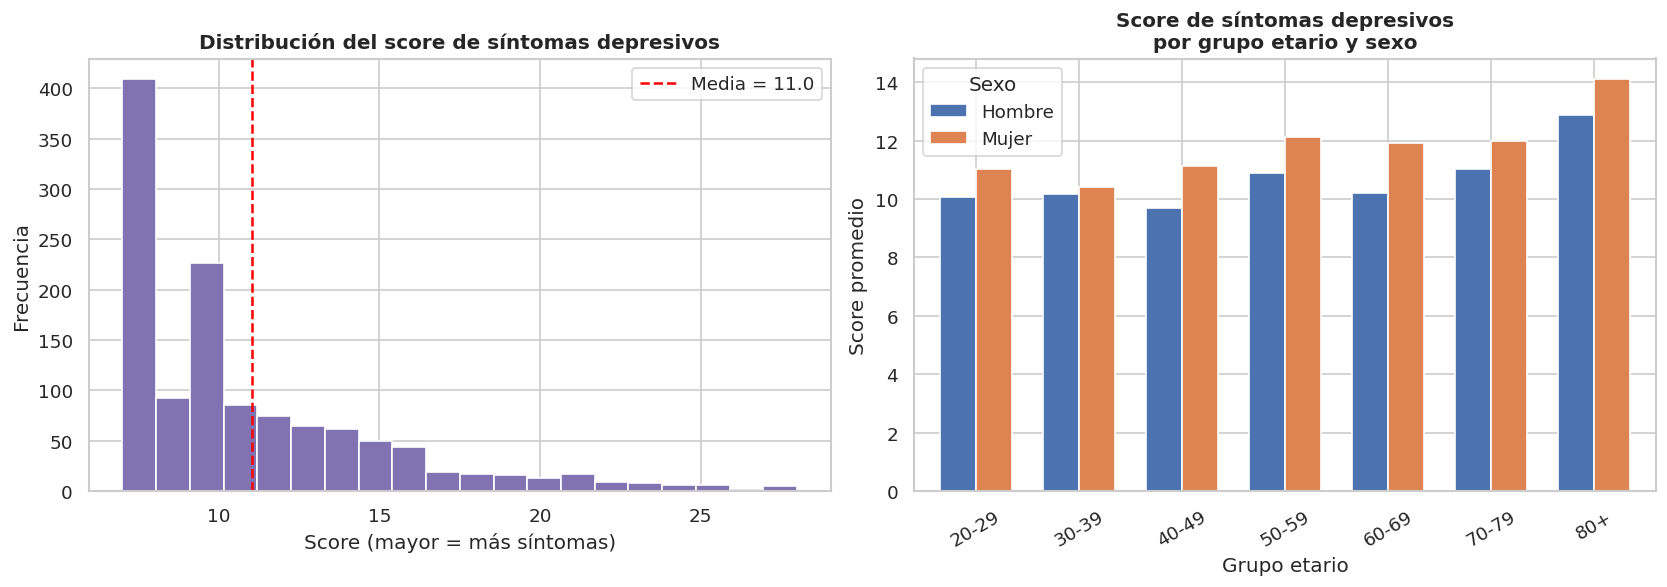

Score promedio: 11.02
        count       mean       std  min  25%   50%   75%   max
Sexo                                                          
Hombre  430.0  10.320930  3.296432  7.0  7.0  10.0  12.0  25.0
Mujer   797.0  11.395232  4.415667  7.0  8.0  10.0  14.0  28.0


In [32]:
if 'Score depresión' in df.columns:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Histograma del score
    ax = axes[0]
    ax.hist(df['Score depresión'].dropna(), bins=20, color='#8172B2', edgecolor='white')
    ax.set_title('Distribución del score de síntomas depresivos', fontweight='bold')
    ax.set_xlabel('Score (mayor = más síntomas)')
    ax.set_ylabel('Frecuencia')
    ax.axvline(df['Score depresión'].mean(), color='red', linestyle='--',
               label=f'Media = {df["Score depresión"].mean():.1f}')
    ax.legend()

    # Score promedio por grupo etario y sexo
    ax = axes[1]
    pivot_dep = df.groupby(['Grupo etario', 'Sexo'], observed=True)['Score depresión'].mean().unstack()
    pivot_dep.plot(kind='bar', ax=ax, color=['#4C72B0', '#DD8452'], edgecolor='white', width=0.7)
    ax.set_title('Score de síntomas depresivos\npor grupo etario y sexo', fontweight='bold')
    ax.set_xlabel('Grupo etario')
    ax.set_ylabel('Score promedio')
    ax.legend(title='Sexo')
    ax.tick_params(axis='x', rotation=30)

    plt.tight_layout()
    plt.savefig('../outputs/figures/2022/eda_score_depresion.png', bbox_inches='tight')
    plt.show()

    print(f"Score promedio: {df['Score depresión'].mean():.2f}")
    print(df.groupby('Sexo')['Score depresión'].describe())

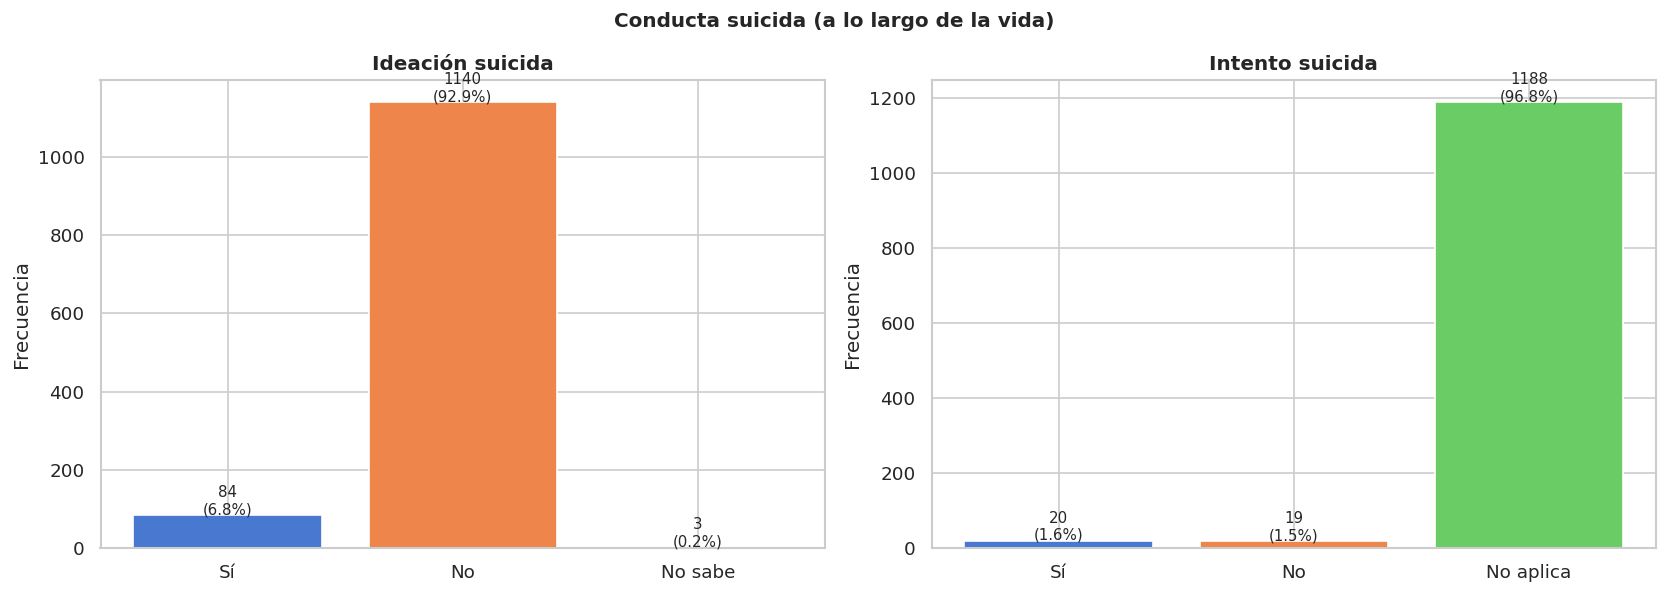

In [33]:
# Ideación suicida e intentos
suicide_cols = {
    'Ideación suicida': 'A1211 ¿Alguna vez ha pensado en suicidarse?',
    'Intento suicida': 'A1213 ¿Alguna vez a propósito se ha herido, cortado, intoxicado o hecho daño con el fin de quitarse la vida?',
}
suicide_cols = {k: v for k, v in suicide_cols.items() if v in df.columns}

if suicide_cols:
    fig, axes = plt.subplots(1, len(suicide_cols), figsize=(7 * len(suicide_cols), 5))
    if len(suicide_cols) == 1:
        axes = [axes]
    for ax, (label, col) in zip(axes, suicide_cols.items()):
        counts = df[col].value_counts().sort_index()
        label_map = {1: 'Sí', 2: 'No', 3: 'No aplica', 9: 'No sabe'}
        counts.index = [label_map.get(i, str(i)) for i in counts.index]
        pcts = counts / counts.sum() * 100
        palette = sns.color_palette('muted', len(counts))
        bars = ax.bar(counts.index, counts.values,
                      color=palette, edgecolor='white')
        ax.set_title(label, fontweight='bold')
        ax.set_ylabel('Frecuencia')
        for bar, val, pct in zip(bars, counts.values, pcts.values):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
                    f'{val}\n({pct:.1f}%)', ha='center', fontsize=9)
    plt.suptitle('Conducta suicida (a lo largo de la vida)', fontweight='bold')
    plt.tight_layout()
    plt.savefig('../outputs/figures/2022/eda_suicidio.png', bbox_inches='tight')
    plt.show()

### 3.4 Estilos de vida

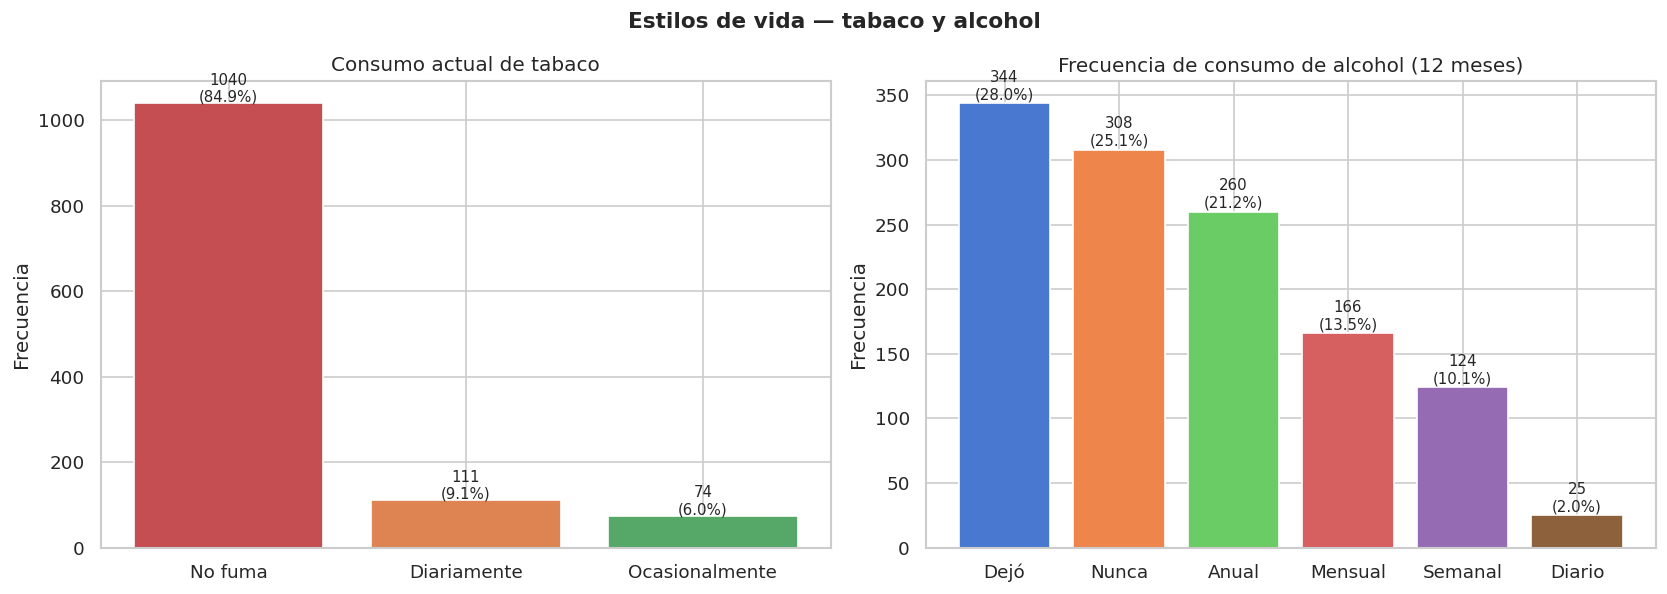

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Estilos de vida — tabaco y alcohol', fontsize=13, fontweight='bold')

# Tabaco actual
col_tab = 'A1301 Actualmente, ¿fuma tabaco…'
if col_tab in df.columns:
    ax = axes[0]
    tab_map = {1: 'Diariamente', 2: 'Ocasionalmente', 3: 'No fuma'}
    counts = df[col_tab].map(tab_map).value_counts()
    bars = ax.bar(counts.index, counts.values,
                  color=['#C44E52', '#DD8452', '#55A868'], edgecolor='white')
    ax.set_title('Consumo actual de tabaco')
    ax.set_ylabel('Frecuencia')
    total = counts.sum()
    for bar, val in zip(bars, counts.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 3,
                f'{val}\n({val/total*100:.1f}%)', ha='center', fontsize=9)

# Alcohol (frecuencia últimos 12 meses)
col_alc = 'A1308 En los últimos 12 meses,¿Con qué frecuencia tomó al menos una copa ya sea de vino, cerveza, whisky o cualquier otra bebida que contenga alcohol?'
if col_alc in df.columns:
    ax = axes[1]
    alc_map = {1: 'Diario', 2: 'Semanal', 3: 'Mensual', 4: 'Anual', 5: 'Nunca', 6: 'Dejó'}
    counts = df[col_alc].map(alc_map).value_counts()
    bars = ax.bar(counts.index, counts.values,
                  color=sns.color_palette('muted', len(counts)), edgecolor='white')
    ax.set_title('Frecuencia de consumo de alcohol (12 meses)')
    ax.set_ylabel('Frecuencia')
    total = counts.sum()
    for bar, val in zip(bars, counts.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 3,
                f'{val}\n({val/total*100:.1f}%)', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('../outputs/figures/2022/eda_estilos_vida.png', bbox_inches='tight')
plt.show()

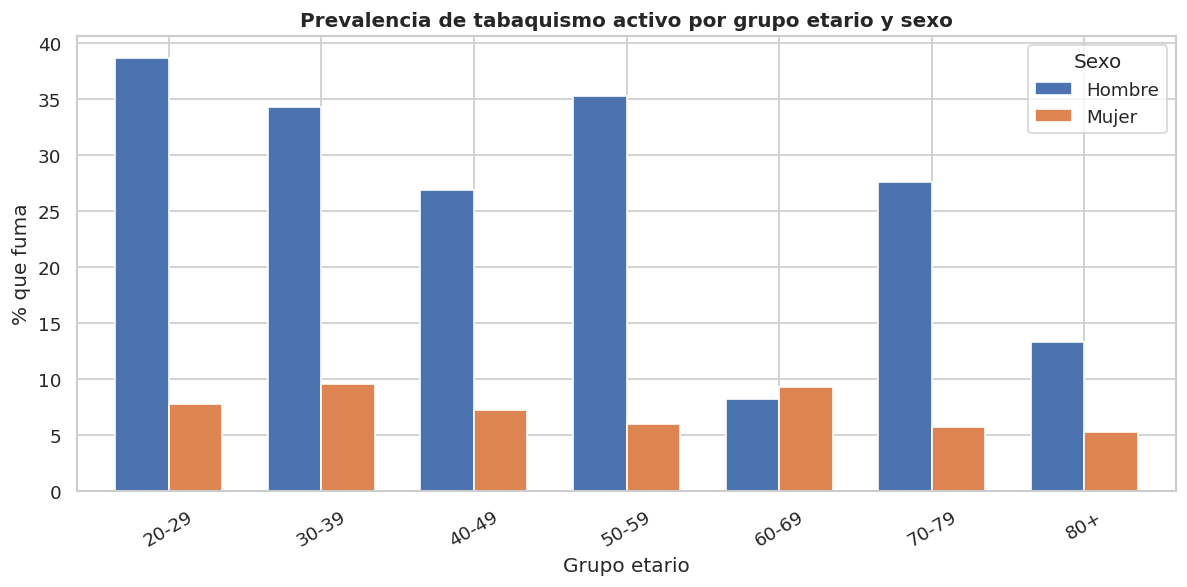

In [35]:
# Tabaco por sexo y grupo etario
col_tab = 'A1301 Actualmente, ¿fuma tabaco…'
if col_tab in df.columns:
    tab_map = {1: 'Fuma', 2: 'Fuma', 3: 'No fuma'}
    df['Fuma actualmente'] = df[col_tab].map(tab_map)

    pivot_tab = df.groupby(['Grupo etario', 'Sexo', 'Fuma actualmente'], observed=True).size().reset_index(name='n')
    pivot_tab['pct'] = pivot_tab.groupby(['Grupo etario', 'Sexo'], observed=True)['n'].transform(lambda x: x/x.sum()*100)
    fuma_pct = pivot_tab[pivot_tab['Fuma actualmente'] == 'Fuma'].pivot_table(
        index='Grupo etario', columns='Sexo', values='pct', observed=True)

    fig, ax = plt.subplots(figsize=(10, 5))
    fuma_pct.plot(kind='bar', ax=ax, color=['#4C72B0','#DD8452'], edgecolor='white', width=0.7)
    ax.set_title('Prevalencia de tabaquismo activo por grupo etario y sexo', fontweight='bold')
    ax.set_xlabel('Grupo etario')
    ax.set_ylabel('% que fuma')
    ax.tick_params(axis='x', rotation=30)
    ax.legend(title='Sexo')
    plt.tight_layout()
    plt.savefig('../outputs/figures/2022/eda_tabaco_edad_sexo.png', bbox_inches='tight')
    plt.show()

### 3.5 Antecedentes familiares de enfermedades

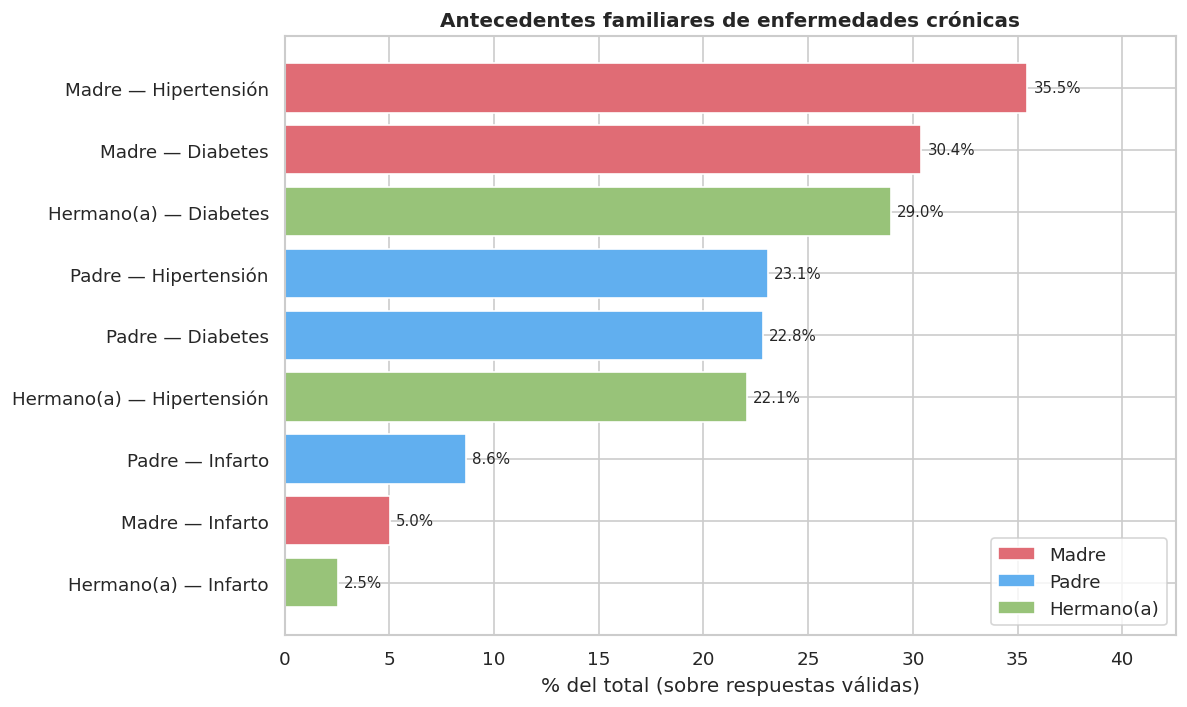

In [36]:
antec_map = {
    'Padre — Diabetes':    '¿Su PADRE tiene o tuvo diabetes o azúcar alta en la sangre?',
    'Padre — Hipertensión':'¿Su PADRE tiene o tuvo hipertensión o presión alta?',
    'Padre — Infarto':     '¿Su PADRE  tuvo un infarto?',
    'Madre — Diabetes':    '¿Su MADRE tiene o tuvo diabetes o azúcar alta en la sangre?',
    'Madre — Hipertensión':'¿Su MADRE tiene o tuvo hipertensión o presión alta?',
    'Madre — Infarto':     '¿Su MADRE  tuvo un infarto?',
    'Hermano(a) — Diabetes':    '¿Su HERMANO(A) tiene o tuvo diabetes o azúcar alta en la sangre?',
    'Hermano(a) — Hipertensión':'¿Su HERMANO(A) tiene o tuvo hipertensión o presión alta?',
    'Hermano(a) — Infarto':     '¿Su HERMANO(A)  tuvo un infarto?',
}
antec_map = {k: v for k, v in antec_map.items() if v in df.columns}

antec_pct = {}
for label, col in antec_map.items():
    valid = df[col].isin([1, 2])
    antec_pct[label] = (df.loc[valid, col] == 1).mean() * 100

antec_series = pd.Series(antec_pct).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#E06C75' if 'Madre' in k else '#61AFEF' if 'Padre' in k else '#98C379'
          for k in antec_series.index]
bars = ax.barh(antec_series.index, antec_series.values, color=colors, edgecolor='white')
ax.set_title('Antecedentes familiares de enfermedades crónicas', fontweight='bold')
ax.set_xlabel('% del total (sobre respuestas válidas)')
for bar, val in zip(bars, antec_series.values):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', fontsize=9)
ax.set_xlim(0, antec_series.max() * 1.2)

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#E06C75', label='Madre'),
                   Patch(facecolor='#61AFEF', label='Padre'),
                   Patch(facecolor='#98C379', label='Hermano(a)')]
ax.legend(handles=legend_elements, loc='lower right')
plt.tight_layout()
plt.savefig('../outputs/figures/2022/eda_antecedentes_familiares.png', bbox_inches='tight')
plt.show()

### 3.6 Discapacidades y dificultades funcionales

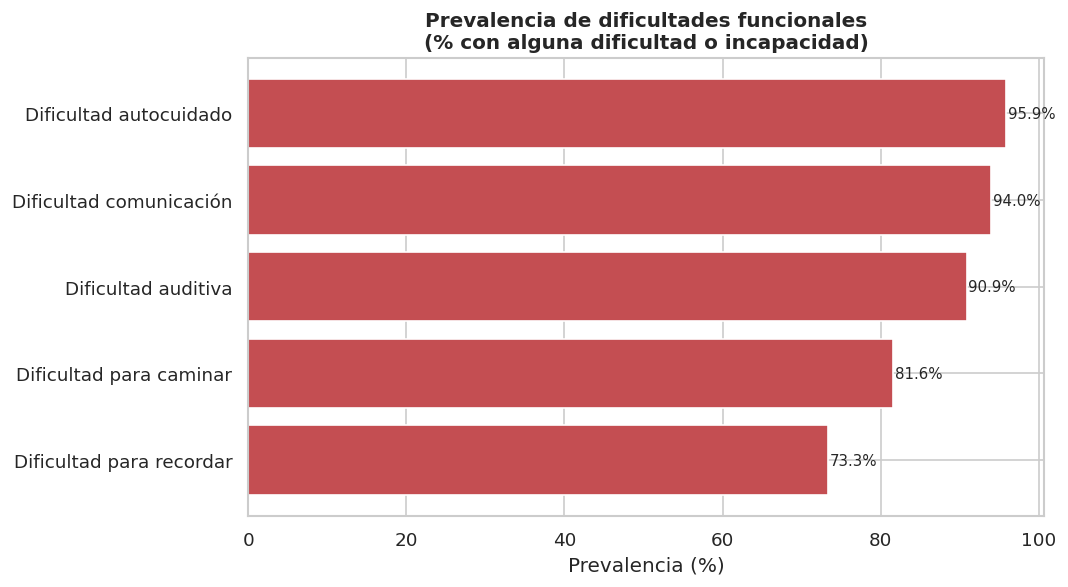

In [37]:
discap_map = {
    'Dificultad auditiva':     'A1404B ¿Tiene dificultades para oír?',
    'Dificultad para caminar': 'A1405 ¿Tiene dificultad para caminar o subir escalones?',
    'Dificultad para recordar':'A1406 ¿Tiene dificultad para recordar o concentrarse?',
    'Dificultad autocuidado':  'A1407 ¿Tiene dificultad para el cuidado propio, tal como lavarse todo el cuerpo o vestirse?',
    'Dificultad comunicación': 'A1408 Usando su idioma habitual, ¿tiene dificultad para comunicarse, por ejemplo, entender a otros o hacerse entender?',
    'Usa anteojos/lentes':     'A1401 ¿Usa anteojos o lentes de contacto?',
    'Usa prótesis auditiva':   'A1402 ¿Usa una prótesis auditiva?',
}
discap_map = {k: v for k, v in discap_map.items() if v in df.columns}
# "Sí" = 1 para lentes/prótesis, pero para dificultades el valor 1=Sí, 2=No, 3=No puede
discap_pct_alguna = {}
for label, col in discap_map.items():
    valid = df[col].isin([1, 2, 3])
    discap_pct_alguna[label] = (df.loc[valid, col] >= 1).mean() * 100  # cualquier afirmativo

# Para dificultades: 1=Sí, 2=No, 3=No puede → "tiene dificultad" = 1 ó 3
dif_cols = {k: v for k, v in discap_map.items()
            if 'Dificultad' in k or 'dificultad' in k}
dif_pct = {}
for label, col in dif_cols.items():
    valid = df[col].isin([1, 2, 3])
    dif_pct[label] = (df.loc[valid, col].isin([1, 3])).mean() * 100

dif_series = pd.Series(dif_pct).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(dif_series.index, dif_series.values, color='#C44E52', edgecolor='white')
ax.set_title('Prevalencia de dificultades funcionales\n(% con alguna dificultad o incapacidad)', fontweight='bold')
ax.set_xlabel('Prevalencia (%)')
for bar, val in zip(bars, dif_series.values):
    ax.text(bar.get_width() + 0.2, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', fontsize=9)
plt.tight_layout()
plt.savefig('../outputs/figures/2022/eda_discapacidades.png', bbox_inches='tight')
plt.show()

### 3.7 Acceso y detección en salud

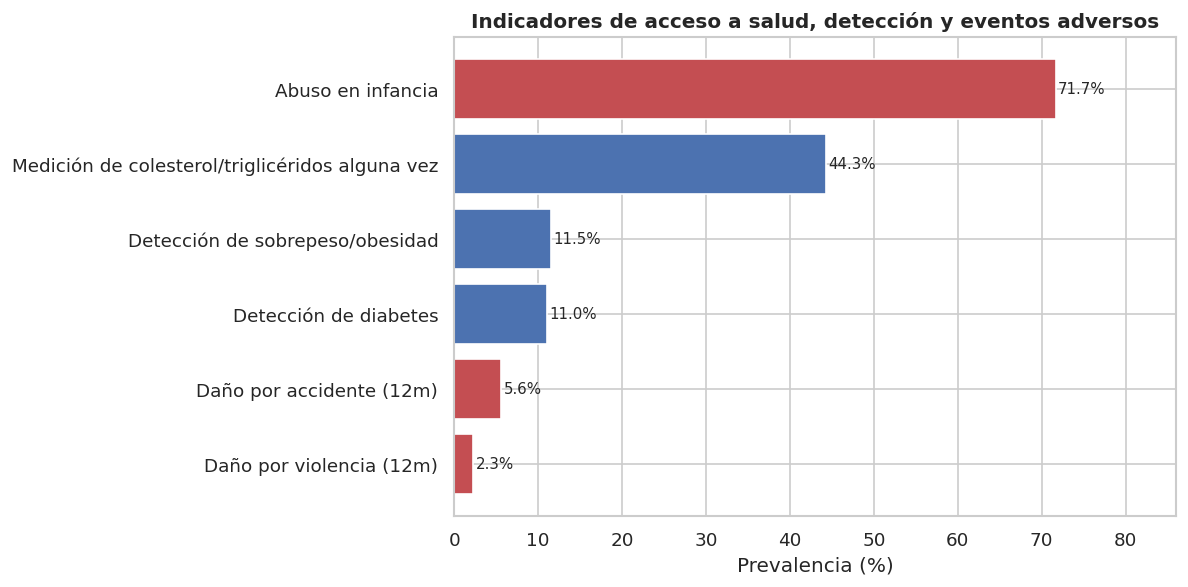

In [38]:
acceso_map = {
    'Medición de colesterol/triglicéridos alguna vez': '¿Le han medido alguna vez la concentración de colesterol y triglicéridos?',
    'Detección de sobrepeso/obesidad': 'A1001F f) detección de sobrepeso u obesidad?',
    'Detección de diabetes': 'A1001G g) detección de diabetes?',
    'Daño por accidente (12m)': 'A1101 ¿Sufrió usted algún daño a su salud a causa de un accidente en los últimos 12 meses?',
    'Daño por violencia (12m)': 'A1201 En los últimos 12 meses, ¿sufrió usted algun daño a su salud por robo, agresión o violencia?',
    'Abuso en infancia': 'A1210 ¿A lo largo de su vida, alguien le manoseó, tocó o acarició alguna parte de su cuerpo o tuvo relaciones sexuales con usted cuando era muy pequeño/a?',
}
acceso_map = {k: v for k, v in acceso_map.items() if v in df.columns}

acceso_pct = {}
for label, col in acceso_map.items():
    valid = df[col].isin([1, 2])
    acceso_pct[label] = (df.loc[valid, col] == 1).mean() * 100

acceso_series = pd.Series(acceso_pct).sort_values()

fig, ax = plt.subplots(figsize=(10, 5))
bar_colors = ['#C44E52' if 'Daño' in k or 'Abuso' in k else '#4C72B0' for k in acceso_series.index]
bars = ax.barh(acceso_series.index, acceso_series.values, color=bar_colors, edgecolor='white')
ax.set_title('Indicadores de acceso a salud, detección y eventos adversos', fontweight='bold')
ax.set_xlabel('Prevalencia (%)')
for bar, val in zip(bars, acceso_series.values):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', fontsize=9)
ax.set_xlim(0, acceso_series.max() * 1.2)
plt.tight_layout()
plt.savefig('../outputs/figures/2022/eda_acceso_salud.png', bbox_inches='tight')
plt.show()

### 3.8 Mapa de correlaciones (variables numéricas de salud)

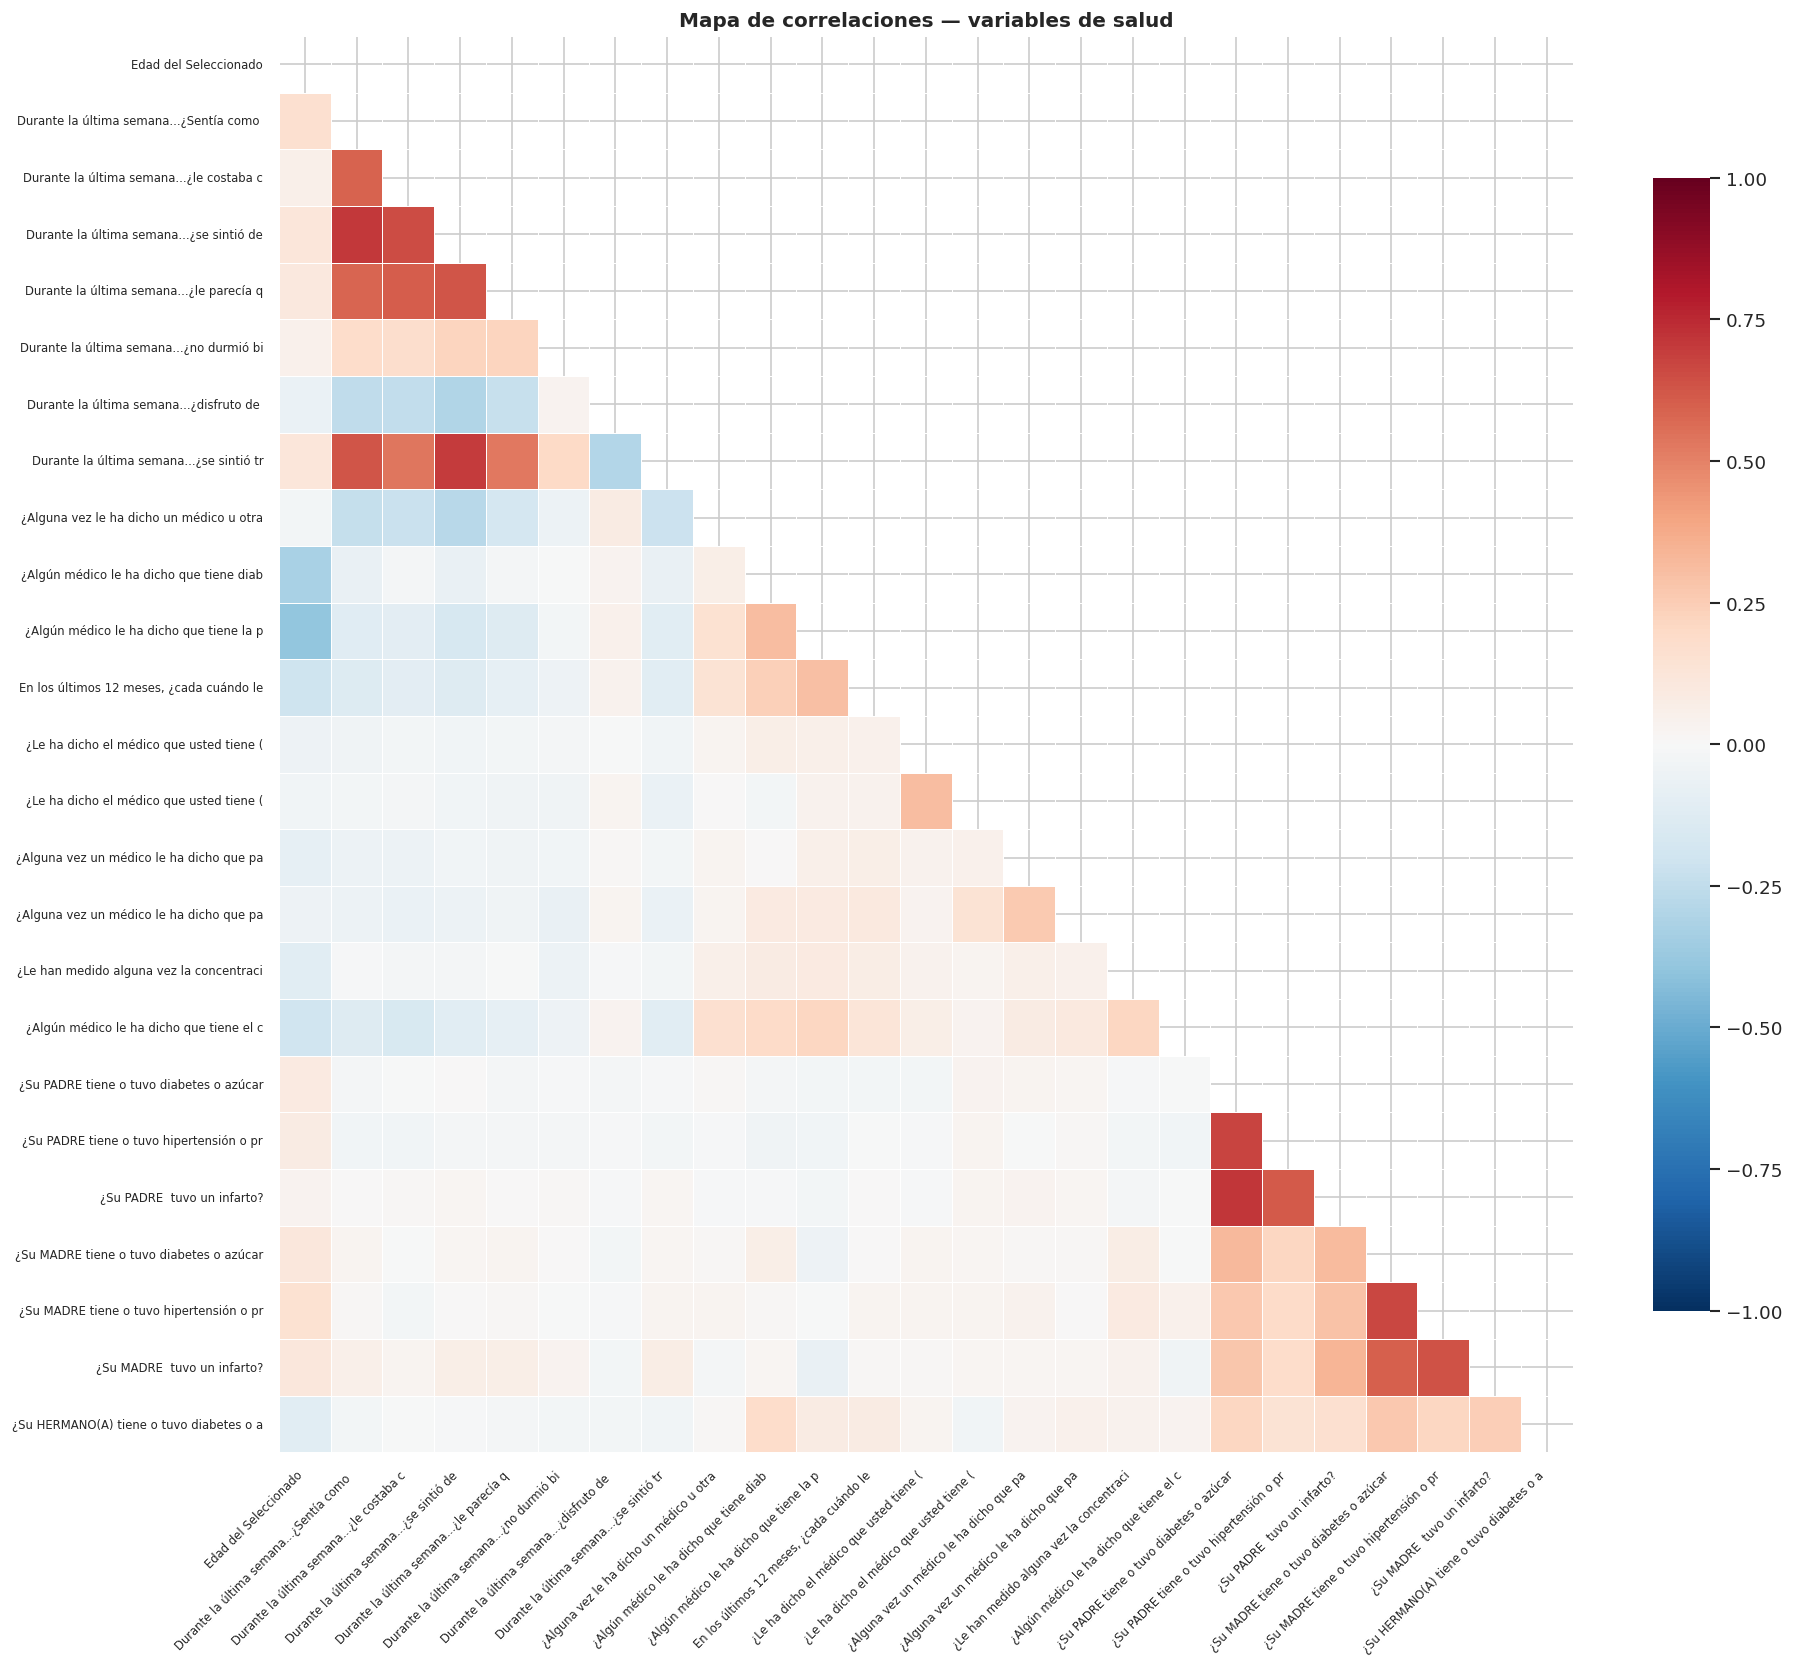

In [39]:
# Seleccionar solo variables numéricas de salud relevantes
health_num_cols = [c for c in df.select_dtypes(include=[np.number]).columns
                   if c not in ['Folio integrante', 'TIEMPO HORA', 'TIEMPO MINUTOS',
                                 'TIEMPO SUMA INICIO', 'TIEMPO SUMA FIN',
                                 'Municipio/Alcaldia', 'Estrato de seleccion',
                                 'Unidad primaria de muestreo', 'Ponderador',
                                 'Estrato urbanidad/ruralidad', 'Sexo del Seleccionado',
                                 'Entidad', 'Region o zona de trabajo']]

# Limitar a máximo 25 columnas para legibilidad
if len(health_num_cols) > 25:
    # Preferir columnas de salud
    priority = [c for c in health_num_cols if any(
        k in c for k in ['diabetes', 'presión', 'Diabetes', 'Presión', 'colesterol',
                          'infarto', 'semana', 'Score', 'Edad', 'tabaco', 'alcohol',
                          'Riñón', 'renal', 'Triglicéridos', 'Depresión', 'suicid',
                          'caminar', 'recordar'])]
    health_num_cols = priority[:25] if len(priority) >= 25 else (priority + [
        c for c in health_num_cols if c not in priority])[:25]

corr_df = df[health_num_cols].copy()
# Limpiar nombres para la visualización
short_names = {c: c[:40] for c in corr_df.columns}
corr_df.rename(columns=short_names, inplace=True)

corr_matrix = corr_df.corr()

fig, ax = plt.subplots(figsize=(16, 14))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=False, cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, ax=ax,
            linewidths=0.3, cbar_kws={'shrink': 0.8})
ax.set_title('Mapa de correlaciones — variables de salud', fontweight='bold', fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=7)
plt.yticks(fontsize=7)
plt.tight_layout()
plt.savefig('../outputs/figures/2022/eda_correlaciones.png', bbox_inches='tight')
plt.show()

### 3.9 Percepción corporal y cambio de peso

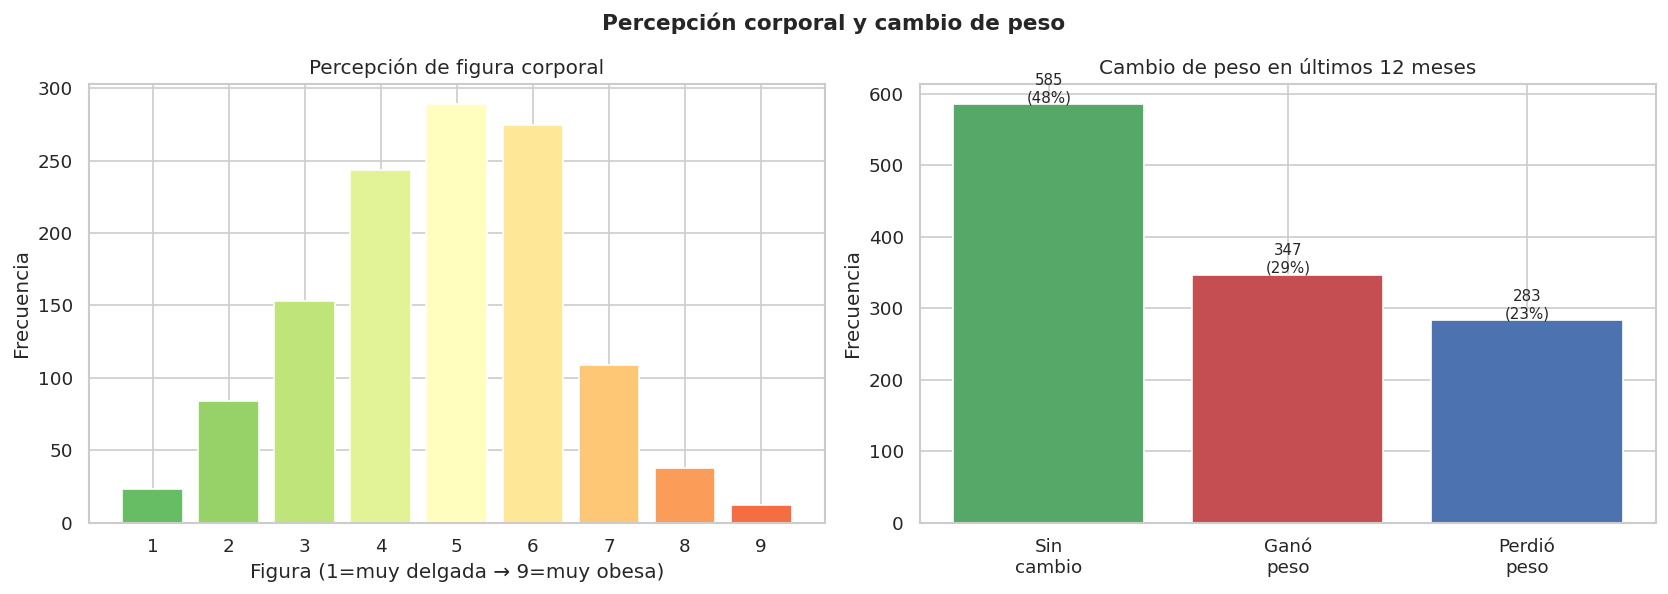

In [40]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Percepción corporal y cambio de peso', fontsize=13, fontweight='bold')

col_fig = 'Ahora le voy a mostrar unas figuras corporales, por favor, dígame qué figura siente que más se parece a usted en este momento'
if col_fig in df.columns:
    ax = axes[0]
    counts = df[col_fig].value_counts().sort_index()
    # Figuras del 1 al 9 (1=muy delgado, 5=peso normal, 9=muy obeso aprox.)
    bars = ax.bar(counts.index.astype(str), counts.values,
                  color=plt.cm.RdYlGn_r(np.linspace(0.2, 0.8, len(counts))), edgecolor='white')
    ax.set_title('Percepción de figura corporal')
    ax.set_xlabel('Figura (1=muy delgada → 9=muy obesa)')
    ax.set_ylabel('Frecuencia')

col_peso = 'Durante los últimos 12 meses, ¿ha perdido o ganado peso?'
if col_peso in df.columns:
    ax = axes[1]
    peso_map = {1: 'Perdió\npeso', 2: 'Ganó\npeso', 3: 'Sin\ncambio', 8: 'No\nsabe'}
    counts = df[col_peso].map(peso_map).value_counts()
    bars = ax.bar(counts.index, counts.values,
                  color=['#55A868', '#C44E52', '#4C72B0', '#8172B2'], edgecolor='white')
    ax.set_title('Cambio de peso en últimos 12 meses')
    ax.set_ylabel('Frecuencia')
    total = counts.sum()
    for bar, val in zip(bars, counts.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 3,
                f'{val}\n({val/total*100:.0f}%)', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('../outputs/figures/2022/eda_peso_corporal.png', bbox_inches='tight')
plt.show()

---
## 4. Resumen ejecutivo

In [41]:
print('=' * 60)
print('RESUMEN — ENSADUL 2022 Guanajuato')
print('=' * 60)
print(f'  Total de encuestados:    {len(df):,}')
print(f'  Variables de análisis:   {len(df.columns)}')
print()
print(f'  Edad promedio:           {df["Edad del Seleccionado"].mean():.1f} años')
print(f'  Mujeres:                 {(df["Sexo"]=="Mujer").sum():,} ({(df["Sexo"]=="Mujer").mean()*100:.1f}%)')
print(f'  Hombres:                 {(df["Sexo"]=="Hombre").sum():,} ({(df["Sexo"]=="Hombre").mean()*100:.1f}%)')
print()
print('  Enfermedades crónicas (prevalencia):')
for label, col in list(enf_cols.items())[:5]:
    valid = df[col].isin([1,2]).sum()
    si = (df[col]==1).sum()
    print(f'    {label:<30} {si/valid*100:.1f}%')
print()
if 'Score depresión' in df.columns:
    print(f'  Score depresión promedio: {df["Score depresión"].mean():.1f} (rango: {df["Score depresión"].min():.0f}-{df["Score depresión"].max():.0f})')
if 'A1211 ¿Alguna vez ha pensado en suicidarse?' in df.columns:
    col_s = 'A1211 ¿Alguna vez ha pensado en suicidarse?'
    valid = df[col_s].isin([1,2]).sum()
    si = (df[col_s]==1).sum()
    print(f'  Ideación suicida alguna vez: {si/valid*100:.1f}%')
print('=' * 60)

RESUMEN — ENSADUL 2022 Guanajuato
  Total de encuestados:    1,227
  Variables de análisis:   67

  Edad promedio:           46.5 años
  Mujeres:                 797 (65.0%)
  Hombres:                 430 (35.0%)

  Enfermedades crónicas (prevalencia):
    Diabetes                       99.4%
    Hipertensión                   99.2%
    Colesterol alto                16.1%
    Triglicéridos altos            14.1%
    Infarto                        2.0%

  Score depresión promedio: 11.0 (rango: 7-28)
  Ideación suicida alguna vez: 6.9%
